## Парная линейная регрессия

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('data/lw4.csv')
df.head()

,x,y
0,3.1459,9.6212
1,3.5190,8.0740
2,3.8066,9.3958
3,4.1410,9.2497
4,4.8160,10.6643


In [2]:
x = df['x'].values
y = df['y'].values
n = len(x)

sxx = ((x - x.mean()) ** 2).sum()
sxy = ((x - x.mean()) * (y - y.mean())).sum()
tss = ((y - y.mean()) ** 2).sum()

print(f'n = {n}, среднее x = {x.mean():.6f}, среднее y = {y.mean():.6f}')
print(f'Sxx = {sxx:.6f}, Sxy = {sxy:.6f}, TSS = {tss:.6f}')

n = 30, среднее x = 9.083297, среднее y = 15.680167
Sxx = 392.755677, Sxy = 471.579808, TSS = 579.181547


In [3]:
b1 = sxy / sxx
b0 = y.mean() - b1 * x.mean()
pred = b0 + b1 * x
rss = ((y - pred) ** 2).sum()
s2 = rss / (n - 2)
s = np.sqrt(s2)

print(f'уравнение: y = {b0:.4f} + {b1:.4f} x')
print(f'RSS = {rss:.6f}, s2 = {s2:.6f}, s = {s:.6f}')
print(f'R2 = {1 - rss / tss:.6f}')

уравнение: y = 4.7739 + 1.2007 x
RSS = 12.957993, s2 = 0.462785, s = 0.680283
R2 = 0.977627


In [4]:
se_b1 = s / np.sqrt(sxx)
se_b0 = s * np.sqrt(1 / n + x.mean() ** 2 / sxx)
tkr = stats.t.ppf(0.975, n - 2)

print(f'SE(b0) = {se_b0:.6f}, SE(b1) = {se_b1:.6f}, t крит = {tkr:.6f}')
print(f'ди для b0: [{b0 - tkr * se_b0:.4f}, {b0 + tkr * se_b0:.4f}]')
print(f'ди для b1: [{b1 - tkr * se_b1:.4f}, {b1 + tkr * se_b1:.4f}]')

SE(b0) = 0.335624, SE(b1) = 0.034326, t крит = 2.048407
ди для b0: [4.0864, 5.4614]
ди для b1: [1.1304, 1.2710]


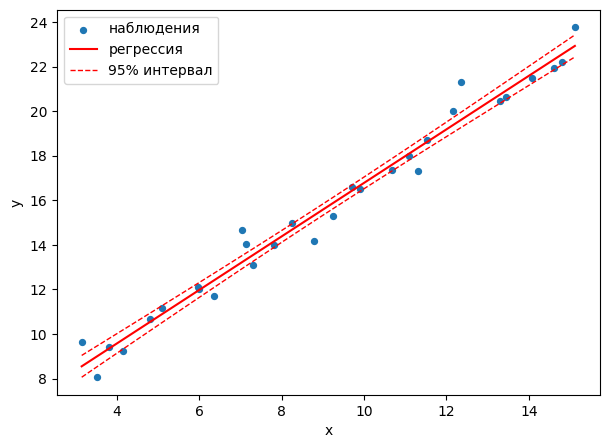

In [5]:
xs = np.linspace(x.min(), x.max(), 100)
ys = b0 + b1 * xs
se_line = s * np.sqrt(1 / n + (xs - x.mean()) ** 2 / sxx)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=18, label='наблюдения')
plt.plot(xs, ys, color='red', label='регрессия')
plt.plot(xs, ys - tkr * se_line, color='red', linestyle='--', linewidth=1)
plt.plot(xs, ys + tkr * se_line, color='red', linestyle='--', linewidth=1, label='95% интервал')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Наклон 1.2007, интервал [1.1304, 1.2710] ноль не накрывает, значит зависимость значима на уровне 5%.

R2 = 0.9776. Полоса самая узкая около среднего x = 9.08 и расширяется к краям выборки.